In [1]:
%matplotlib notebook

import numpy as np
import pandas as pd

from scipy.optimize import leastsq
from matplotlib import pyplot as plt

from thermo import *

In [16]:
mt = load_melt('./data/2021-05-12_110813_MeltCurve Data.txt')
wt = load_melt('./data/MproWT_thermal_melt_MeltCurve Data.txt')

mdf = pd.DataFrame(mt)
wt  = pd.DataFrame(wt)

,temperature,A10,A11,A12,B10,B11,B12,C10,C11,C12,...,E12,F10,F11,F12,G10,G11,G12,H10,H11,H12
0,24.913,-1144.751,473.183,-627.177,543.219,774.418,863.188,-75.635,848.092,593.223,...,225.816,1114.868,779.143,17.064,780.261,406.587,48.157,191.454,217.425,329.837
1,25.028,-905.159,432.647,-579.434,560.776,891.497,941.829,-43.508,840.091,570.744,...,212.408,1039.208,754.982,41.799,767.652,403.730,9.711,173.394,177.116,319.087
2,25.142,-659.505,451.532,-540.652,568.042,1020.415,1032.598,-19.907,828.621,556.026,...,201.521,976.811,709.952,68.923,739.280,384.154,-28.473,139.601,132.890,290.156
3,25.257,-469.428,521.136,-482.065,561.358,1147.001,1132.434,1.947,809.990,544.447,...,189.907,934.272,639.039,97.284,693.450,343.827,-59.795,94.212,82.066,243.975
4,25.371,-375.954,614.004,-373.775,545.520,1258.042,1237.827,32.143,781.116,531.606,...,174.539,912.172,547.534,124.911,636.812,284.205,-78.079,46.163,22.653,195.192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,94.329,131.385,-139.083,140.395,2140.917,3485.456,2050.561,1430.597,2214.222,2068.568,...,8097.453,5374.491,3540.717,6182.349,3661.036,2677.550,1161.176,800.259,1127.670,1006.526
607,94.444,227.388,-102.249,-202.762,2123.550,3364.873,1872.984,1392.849,2178.004,1994.781,...,7674.296,5092.208,3281.379,6524.187,3800.069,2743.239,984.096,867.234,1236.478,1060.699
608,94.558,362.785,-88.102,-571.242,2128.319,3266.004,1712.724,1385.180,2113.954,1919.162,...,7112.050,4906.236,3045.745,6937.178,3877.500,2826.251,734.480,902.130,1348.171,1111.025
609,94.673,497.355,-98.055,-886.381,2144.028,3204.333,1593.883,1373.995,2030.756,1860.386,...,6497.054,4873.088,2842.374,7360.264,3916.790,2932.003,500.025,916.207,1455.786,1142.631


In [21]:
# Column key:
#  4,5,6 --> N214A
#  7,8,9 --> Q256A
#  10,11,12 --> S284A
#  [10,11,12 --> wt]

def expand_cols(cols):
    
    rows = ['B', 'C', 'D', 'E', 'F', 'G', 'H']
    wells = []
    
    
    for row in rows:
        for col in cols:
            wells.append('%s%d' % (row, col))
    
    return wells

wt = wt[['temperature'] + expand_cols([10,11,12])]

n214a = mdf[['temperature'] + expand_cols([4,5,6])]
q256a = mdf[['temperature'] + expand_cols([7,8,9])]
s284a = mdf[['temperature'] + expand_cols([10,11,12])]
s284a

,temperature,B10,B11,B12,C10,C11,C12,D10,D11,D12,...,E12,F10,F11,F12,G10,G11,G12,H10,H11,H12
0,24.897,-1098.954,-1564.976,-618.924,-348.869,-338.711,517.357,1435.310,-1207.398,111.040,...,325.082,-253.257,483.891,444.225,217.700,782.906,563.208,464.025,245.901,-164.569
1,25.011,-890.154,-1353.480,-461.653,-281.453,-232.515,558.170,1392.753,-1074.459,103.180,...,324.697,-206.889,463.954,446.833,228.328,750.280,573.810,437.136,244.855,-155.896
2,25.125,-639.355,-1077.757,-251.014,-204.437,-120.040,607.032,1329.926,-944.836,87.701,...,320.442,-171.670,437.134,431.840,236.488,700.846,585.243,421.307,234.132,-144.614
3,25.239,-364.756,-748.355,2.542,-112.035,-0.233,667.449,1251.649,-817.998,71.603,...,315.983,-143.958,407.261,398.877,241.815,638.054,589.646,412.546,216.164,-125.865
4,25.354,-92.932,-398.661,266.882,4.011,127.311,737.898,1171.976,-690.746,65.544,...,314.792,-115.302,381.364,356.036,243.009,573.773,578.357,403.236,197.811,-95.586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,94.330,108.333,1243.679,495.658,-153.985,-1395.548,-775.137,197.975,951.299,-882.856,...,1645.185,2787.544,3140.255,3630.011,3191.606,2169.462,2969.942,1438.210,1830.571,1410.522
609,94.444,126.796,1201.112,443.758,-102.516,-1433.528,-753.562,173.179,984.088,-934.205,...,288.780,2699.867,3019.230,3712.030,3119.868,2085.274,3173.663,1379.254,1869.550,1539.055
610,94.558,121.152,1135.951,374.498,-97.392,-1422.542,-731.205,158.000,1011.915,-945.700,...,-1124.508,2707.168,2998.111,3764.062,3091.102,2020.374,3386.248,1310.176,1920.062,1659.581
611,94.672,95.417,1058.284,291.018,-139.515,-1385.728,-732.271,140.641,1037.332,-928.242,...,-2468.761,2772.703,3033.710,3774.581,3114.709,1955.377,3553.396,1252.918,1961.493,1743.605


<IPython.core.display.Javascript object>


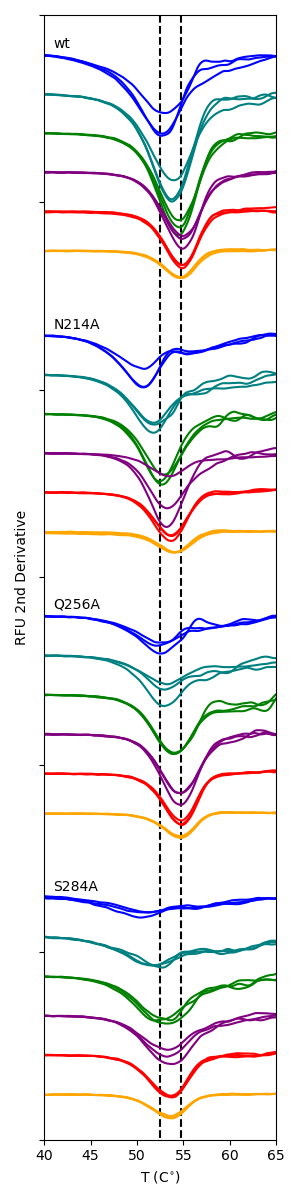

In [62]:
high_T_cutoff = 400

datasets = ['wt', 'N214A', 'Q256A', 'S284A']
colors = ['k', 'b', 'teal', 'green', 'purple', 'r', 'orange']

plt.figure(figsize=(3,12))
ax = plt.subplot(111)

for idf, df in enumerate([wt, n214a, q256a, s284a]):
    
    
    
    T = df.to_numpy()[:high_T_cutoff,0]
    x = df.to_numpy()[:high_T_cutoff,1:]
    
    for i in range(1, x.shape[1]//3):        
        offset = i * 21000 + idf * 150000

        if i == 1:
            plt.text(41, x[0,i*3 + j] - offset + 3000, datasets[idf])
        
        for j in range(3):    
            ax.plot(T, x[:,i*3 + j] - offset, color=colors[i], label=mylabel)
            


ax.set_yticklabels([])
plt.xlim([40, 65])
plt.ylim([-600000, 0])
            
plt.xlabel('T (C$^{\circ}$)')
plt.ylabel('RFU 2nd Derivative')

plt.vlines([52.5, 54.7], 0, -600000, 'k', linestyle='dashed')

plt.tight_layout()
plt.show()